# Model: LSTM

## Input features
Baseline model: Only load
Cyclical model (feature engineering): Load + 6 cyclical encodings
Lookback window: 24 hours

## CV - 4 folds
CV1: Train 2015, Validate 2016

CV2: Train 2015-2016, Validate 2017

CV3: Train 2015-2017, Validate 2018

CV4: Train 2015-2018, Validate 2019

## Architecture
Layers (2): LSTM(64) → Dropout → LSTM(32) → Dropout → Dense(1)

Layers (3): LSTM(64) → Dropout → LSTM(64) → Dropout → LSTM(32) → Dropout → Dense(1)

Layers (4): LSTM(128) → Dropout → LSTM(64) → Dropout → LSTM(64) → Dropout → LSTM(32) → Dropout → Dense(1)

## Hyperparameter tuning
Tuned parameters: Number of layers [2,3,4], dropout rate [0.2,0.3]

## Forecast horizon evaluated
6-hour, 12-hour, and 24-hour

## Evaluation metrics
RMSE (MW), MAPE (%)

## 1. Exploratory Data Analysis (EDA)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
LSTM_data =pd.read_csv (r"C:\Users\emran\Desktop\Kaggle_BENV0148\continuous dataset.csv", parse_dates=['datetime'], index_col='datetime')

In [3]:
#Explore the dataset
print("Data shape:", LSTM_data.shape)
print("\nData info:")
print(LSTM_data.info())
print("\nFirst few rows:")
print(LSTM_data.head())
print("\nColumn names:")
print(LSTM_data.columns.tolist())

Data shape: (48048, 16)

Data info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 48048 entries, 2015-01-03 01:00:00 to 2020-06-27 00:00:00
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   nat_demand  48048 non-null  float64
 1   T2M_toc     48048 non-null  float64
 2   QV2M_toc    48048 non-null  float64
 3   TQL_toc     48048 non-null  float64
 4   W2M_toc     48048 non-null  float64
 5   T2M_san     48048 non-null  float64
 6   QV2M_san    48048 non-null  float64
 7   TQL_san     48048 non-null  float64
 8   W2M_san     48048 non-null  float64
 9   T2M_dav     48048 non-null  float64
 10  QV2M_dav    48048 non-null  float64
 11  TQL_dav     48048 non-null  float64
 12  W2M_dav     48048 non-null  float64
 13  Holiday_ID  48048 non-null  int64  
 14  holiday     48048 non-null  int64  
 15  school      48048 non-null  int64  
dtypes: float64(13), int64(3)
memory usage: 6.2 MB
None

First few rows:
         

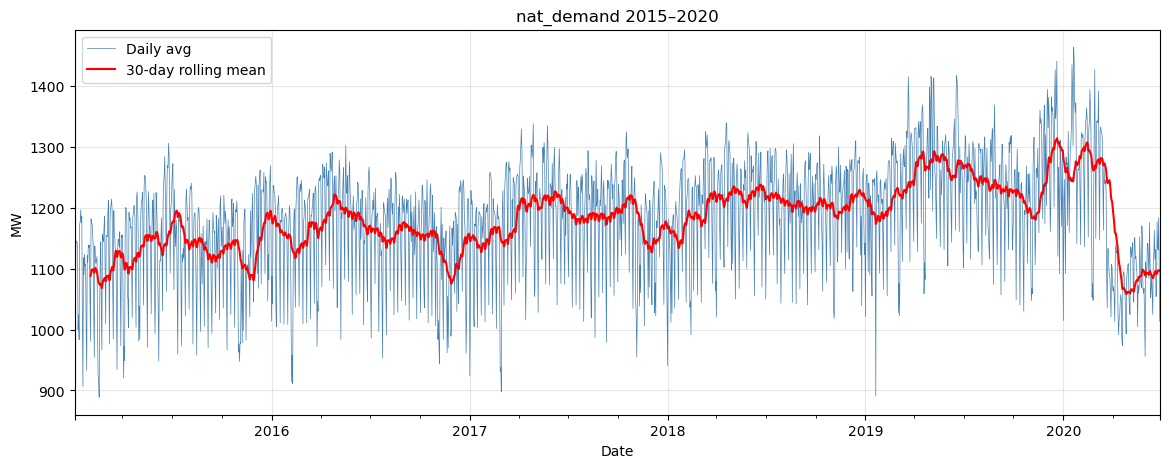

In [4]:
plt.figure(figsize=(14, 5))
LSTM_data['nat_demand'].resample('D').mean().plot(color='steelblue', linewidth=0.5, label='Daily avg')
LSTM_data['nat_demand'].resample('D').mean().rolling(30).mean().plot(color='red', linewidth=1.5, label='30-day rolling mean')
plt.title('nat_demand 2015–2020')
plt.xlabel('Date')
plt.ylabel('MW')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

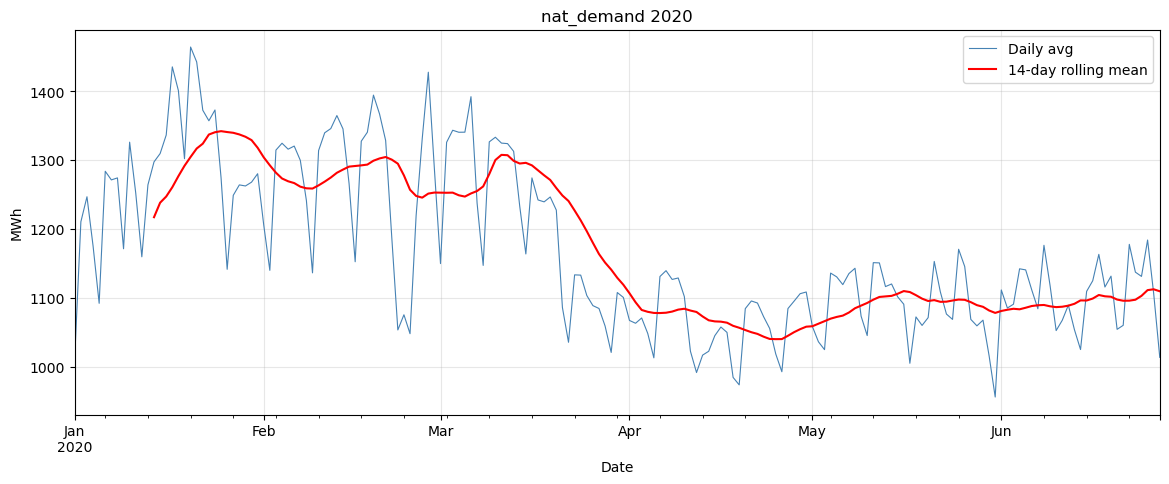

In [5]:
plt.figure(figsize=(14, 5))
df_2020 = LSTM_data.loc['2020-01-01':'2020-12-31']
df_2020['nat_demand'].resample('D').mean().plot(color='steelblue', linewidth=0.8, label='Daily avg')
df_2020['nat_demand'].resample('D').mean().rolling(14).mean().plot(color='red', linewidth=1.5, label='14-day rolling mean')
plt.title('nat_demand 2020')
plt.xlabel('Date')
plt.ylabel('MWh')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

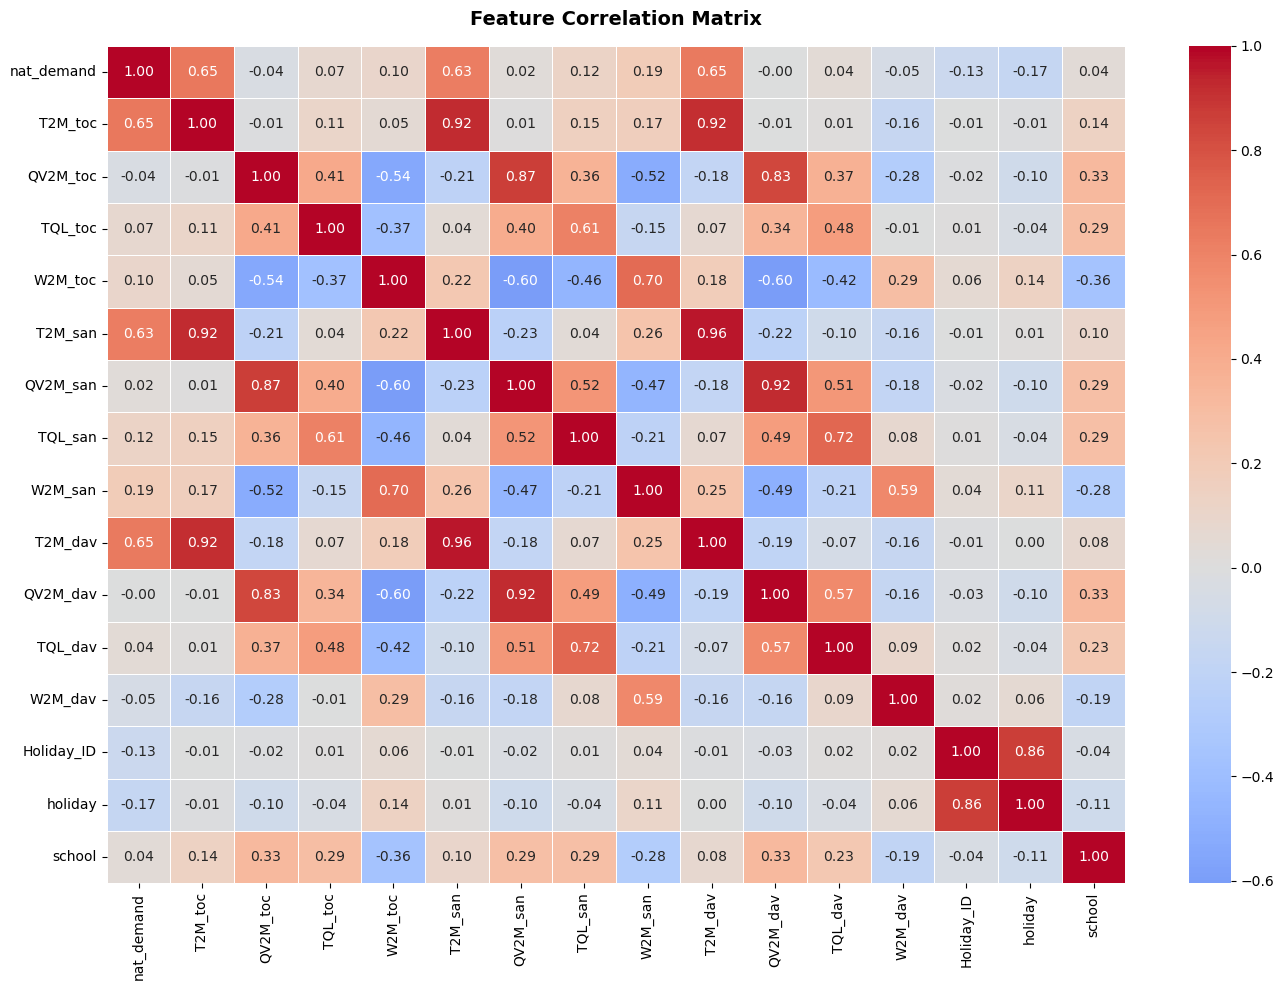

In [6]:
plt.figure(figsize=(14, 10))
sns.heatmap(LSTM_data.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 2. Data Preprocessing

Data after preprocessing: (45191, 16)
                     nat_demand    T2M_toc  QV2M_toc   TQL_toc    W2M_toc  \
datetime                                                                    
2015-01-03 01:00:00    970.3450  25.865259  0.018576  0.016174  21.850546   
2015-01-03 02:00:00    912.1755  25.899255  0.018653  0.016418  22.166944   
2015-01-03 03:00:00    900.2688  25.937280  0.018768  0.015480  22.454911   
2015-01-03 04:00:00    889.9538  25.957544  0.018890  0.016273  22.110481   
2015-01-03 05:00:00    893.6865  25.973840  0.018981  0.017281  21.186089   

                       T2M_san  QV2M_san   TQL_san    W2M_san    T2M_dav  \
datetime                                                                   
2015-01-03 01:00:00  23.482446  0.017272  0.001855  10.328949  22.662134   
2015-01-03 02:00:00  23.399255  0.017265  0.001327  10.681517  22.578943   
2015-01-03 03:00:00  23.343530  0.017211  0.001428  10.874924  22.531030   
2015-01-03 04:00:00  23.238794  0.017128  

C:\Users\emran\AppData\Local\Temp\ipykernel_26484\769802012.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  LSTM_data[load_col] = LSTM_data[load_col].fillna(method='ffill').fillna(method='bfill')


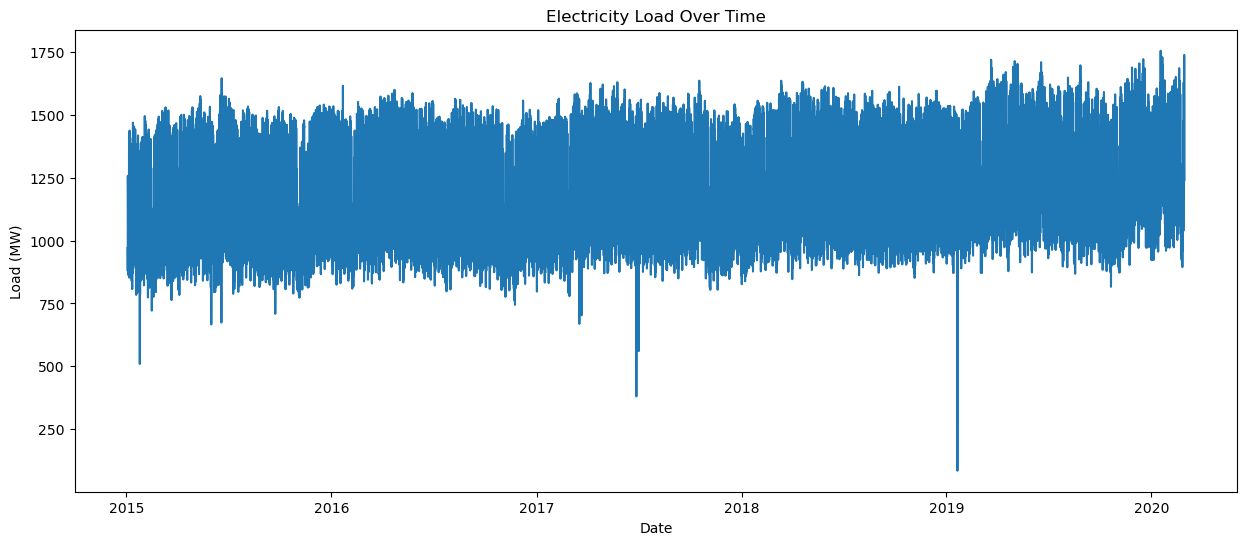

In [7]:
#Data Preprocessing
load_col = 'nat_demand'

LSTM_data[load_col] = LSTM_data[load_col].fillna(method='ffill').fillna(method='bfill')

start_date = '2015-01-01'
end_date = '2020-02-28'
LSTM_data = LSTM_data.loc[start_date:end_date]

print(f"Data after preprocessing: {LSTM_data.shape}")
print(LSTM_data.head())

plt.figure(figsize=(15, 6))
plt.plot(LSTM_data.index, LSTM_data[load_col])
plt.title('Electricity Load Over Time')
plt.xlabel('Date')
plt.ylabel('Load (MW)')
plt.show()

## 3. Feature Engineering

In [8]:
#Define Cross-Validation splits
cv_splits = [
    {'train_years': [2015], 'val_year': 2016},
    {'train_years': [2015, 2016], 'val_year': 2017},
    {'train_years': [2015, 2016, 2017], 'val_year': 2018},
    {'train_years': [2015, 2016, 2017, 2018], 'val_year': 2019}
]

for i, cv in enumerate(cv_splits, 1):
    print(f"CV{i}: Train {cv['train_years']}, Validate {cv['val_year']}")

#Create sequences of 24 hours to predict next hour
def create_sequences(data, seq_length=24):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

#Normalise data
scaler = MinMaxScaler()
train_mask = LSTM_data.index.year < 2020
scaler.fit(LSTM_data.loc[train_mask,[load_col]])
scaled_load = scaler.transform(LSTM_data[[load_col]])

#Create sequences
seq_length = 24
X, y = create_sequences(scaled_load.flatten(), seq_length)

print(f"Sequences shape: X={X.shape}, y={y.shape}")

#Split data
data_by_year = {}
for year in range(2015, 2021):
    mask = (LSTM_data.index.year == year)
    data_by_year[year] = scaled_load[mask]

print("Data points per year:")
for year, data in data_by_year.items():
    print(f"{year}: {len(data)}")

CV1: Train [2015], Validate 2016
CV2: Train [2015, 2016], Validate 2017
CV3: Train [2015, 2016, 2017], Validate 2018
CV4: Train [2015, 2016, 2017, 2018], Validate 2019
Sequences shape: X=(45167, 24), y=(45167,)
Data points per year:
2015: 8711
2016: 8784
2017: 8760
2018: 8760
2019: 8760
2020: 1416


In [9]:
#Extract cyclical features
def create_cyclical_features(df):
    df_features = pd.DataFrame(index=df.index)
    
    #Hour of day
    hour = df.index.hour
    df_features['hour_sin'] = np.sin(2 * np.pi * hour / 24)
    df_features['hour_cos'] = np.cos(2 * np.pi * hour / 24)
    
    #Day of week
    dow = df.index.dayofweek
    df_features['dow_sin'] = np.sin(2 * np.pi * dow / 7)
    df_features['dow_cos'] = np.cos(2 * np.pi * dow / 7)
    
    #Month of year
    month = df.index.month
    df_features['month_sin'] = np.sin(2 * np.pi * (month - 1) / 12)
    df_features['month_cos'] = np.cos(2 * np.pi * (month - 1) / 12)
    
    return df_features

#Create cyclical features
cyclical_features = create_cyclical_features(LSTM_data)

#Combine load with cyclical features
df_combined = pd.DataFrame({
    'load': LSTM_data[load_col],
    'hour_sin': cyclical_features['hour_sin'],
    'hour_cos': cyclical_features['hour_cos'],
    'dow_sin': cyclical_features['dow_sin'],
    'dow_cos': cyclical_features['dow_cos'],
    'month_sin': cyclical_features['month_sin'],
    'month_cos': cyclical_features['month_cos']
})

print("Combined features shape:", df_combined.shape)
print("Features:", df_combined.columns.tolist())
print("\nFirst few rows:")
print(df_combined.head())

#Normalise all features
scaler_combined = MinMaxScaler()
scaled_combined = scaler_combined.fit_transform(df_combined)

#Normalise only load separately for inverse transform
scaler_load = MinMaxScaler()
train_mask_combined = df_combined.index.year < 2020
scaler_load.fit(df_combined.loc[train_mask_combined, ['load']])
load_scaled=scaler_load.transform(df_combined[['load']])

#Create sequences with multiple features
def create_sequences_multifeature(data, seq_length=24):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])  # Shape: (seq_length, n_features)
        y.append(data[i+seq_length, 0])  # Only use load for target
    return np.array(X), np.array(y)

#Cyclical features sequence
seq_length = 24
X_cyclic, y_cyclic = create_sequences_multifeature(scaled_combined, seq_length)

print(f"\nSequences with cyclical encoding:")
print(f"  X shape: {X_cyclic.shape}  (batch_size, seq_length, n_features)")
print(f"  y shape: {y_cyclic.shape}  (batch_size)")

#Split data
data_by_year_cyclic = {}
for year in range(2015, 2021):
    mask = (LSTM_data.index.year == year)
    data_by_year_cyclic[year] = scaled_combined[mask]

print("\nData points per year (with cyclical features):")
for year, data in data_by_year_cyclic.items():
    print(f"{year}: {len(data)}")

Combined features shape: (45191, 7)
Features: ['load', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

First few rows:
                         load  hour_sin  hour_cos   dow_sin   dow_cos  \
datetime                                                                
2015-01-03 01:00:00  970.3450  0.258819  0.965926 -0.974928 -0.222521   
2015-01-03 02:00:00  912.1755  0.500000  0.866025 -0.974928 -0.222521   
2015-01-03 03:00:00  900.2688  0.707107  0.707107 -0.974928 -0.222521   
2015-01-03 04:00:00  889.9538  0.866025  0.500000 -0.974928 -0.222521   
2015-01-03 05:00:00  893.6865  0.965926  0.258819 -0.974928 -0.222521   

                     month_sin  month_cos  
datetime                                   
2015-01-03 01:00:00        0.0        1.0  
2015-01-03 02:00:00        0.0        1.0  
2015-01-03 03:00:00        0.0        1.0  
2015-01-03 04:00:00        0.0        1.0  
2015-01-03 05:00:00        0.0        1.0  

Sequences with cyclical encoding:
 

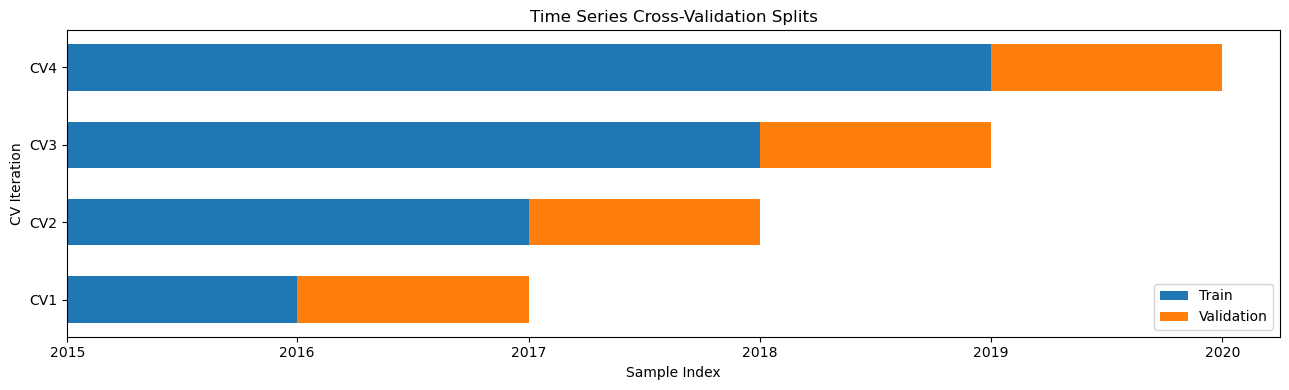

In [10]:
#Time Series Split Visualization
def plot_ts_splits(cv_splits, data_by_year):
    fig, ax = plt.subplots(figsize=(13, 4))

    years = sorted(data_by_year.keys())
    year_start = {}
    cum = 0
    for yr in years:
        year_start[yr] = cum
        cum += len(data_by_year[yr])

    for i, cv in enumerate(cv_splits):
        for j, yr in enumerate(cv['train_years']):
            label = 'Train' if i == 0 and j == 0 else ''
            ax.barh(i, len(data_by_year[yr]), left=year_start[yr],
                    height=0.6, color='#1f77b4', label=label)
        v = cv['val_year']
        label = 'Validation' if i == 0 else ''
        ax.barh(i, len(data_by_year[v]), left=year_start[v],
                height=0.6, color='#ff7f0e', label=label)

    ax.set_xticks([year_start[yr] for yr in years])
    ax.set_xticklabels(years)
    ax.set_yticks(range(len(cv_splits)))
    ax.set_yticklabels([f'CV{i+1}' for i in range(len(cv_splits))])
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('CV Iteration')
    ax.set_title('Time Series Cross-Validation Splits')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

plot_ts_splits(cv_splits, data_by_year)

## 4. Model Training

In [11]:
#Evaluation Functions
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    return mean_absolute_percentage_error(y_true, y_pred) * 100

def evaluate_model(y_true, y_pred):
    return {
        'RMSE': rmse(y_true, y_pred),
        'MAPE': mape(y_true, y_pred)
    }

def get_cv_data(cv_split, data_by_year, seq_length=24):
    train_years = cv_split['train_years']
    val_year = cv_split['val_year']
    
    train_data = np.concatenate([data_by_year[year].flatten() for year in train_years])
    
    X_train, y_train = create_sequences(train_data, seq_length)
    
    val_data = data_by_year[val_year].flatten()
    val_data_ctx = np.concatenate([train_data[-seq_length:], val_data])
    X_val, y_val = create_sequences(val_data_ctx, seq_length)
    
    return X_train, y_train, X_val, y_val

In [12]:
#LSTM Model - 3 hidden layers
def create_lstm_model(seq_length, n_layers=3, dropout_rate=0.2):
    inputs = Input(shape=(seq_length, 1))
    
    if n_layers == 2:
        x = LSTM(64, return_sequences=True)(inputs)
        x = Dropout(dropout_rate)(x)
        x = LSTM(32, return_sequences=False)(x)
        x = Dropout(dropout_rate)(x)
    
    elif n_layers == 3:
        x = LSTM(64, return_sequences=True)(inputs)
        x = Dropout(dropout_rate)(x)
        x = LSTM(64, return_sequences=True)(x)
        x = Dropout(dropout_rate)(x)
        x = LSTM(32, return_sequences=False)(x)
        x = Dropout(dropout_rate)(x)
    
    elif n_layers == 4:
        x = LSTM(128, return_sequences=True)(inputs)
        x = Dropout(dropout_rate)(x)
        x = LSTM(64, return_sequences=True)(x)
        x = Dropout(dropout_rate)(x)
        x = LSTM(64, return_sequences=True)(x)
        x = Dropout(dropout_rate)(x)
        x = LSTM(32, return_sequences=False)(x)
        x = Dropout(dropout_rate)(x)
    
    outputs = Dense(1)(x)
    
    model = Model(inputs=inputs, outputs=outputs, name=f'LSTM_{n_layers}layers')
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    return model

#Train and evaluate
def train_evaluate_lstm(cv_split, data_by_year, seq_length=24, n_layers=3, dropout_rate=0.2, epochs=50, batch_size=32):
    X_train, y_train, X_val, y_val = get_cv_data(cv_split, data_by_year, seq_length)
    
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
    
    model = create_lstm_model(seq_length, n_layers, dropout_rate)
    
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val, y_val), callbacks=[early_stop], verbose=0)
    
    y_pred = model.predict(X_val)
    
    y_val_inv = scaler.inverse_transform(y_val.reshape(-1, 1)).flatten()
    y_pred_inv = scaler.inverse_transform(y_pred).flatten()
    
    metrics = evaluate_model(y_val_inv, y_pred_inv)
    
    return metrics, model

In [13]:
#Cyclical features
def get_cv_data_cyclic(cv_split, data_by_year_cyclic, seq_length=24):
    train_years = cv_split['train_years']
    val_year = cv_split['val_year']
    
    #Concatenate training data
    train_data = np.concatenate([data_by_year_cyclic[year] for year in train_years])
    val_data = data_by_year_cyclic[val_year]
    val_data_ctx = np.concatenate([train_data[-seq_length:], val_data])
    
    #Create sequences
    X_train, y_train = create_sequences_multifeature(train_data, seq_length)
    X_val, y_val = create_sequences_multifeature(val_data_ctx, seq_length)
    
    return X_train, y_train, X_val, y_val

def create_lstm_model_cyclic(seq_length, n_features=7, n_layers=3, dropout_rate=0.2):
    inputs = Input(shape=(seq_length, n_features))
    
    if n_layers == 2:
        x = LSTM(64, return_sequences=True)(inputs)
        x = Dropout(dropout_rate)(x)
        x = LSTM(32, return_sequences=False)(x)
        x = Dropout(dropout_rate)(x)
    
    elif n_layers == 3:
        x = LSTM(64, return_sequences=True)(inputs)
        x = Dropout(dropout_rate)(x)
        x = LSTM(64, return_sequences=True)(x)
        x = Dropout(dropout_rate)(x)
        x = LSTM(32, return_sequences=False)(x)
        x = Dropout(dropout_rate)(x)
    
    elif n_layers == 4:
        x = LSTM(128, return_sequences=True)(inputs)
        x = Dropout(dropout_rate)(x)
        x = LSTM(64, return_sequences=True)(x)
        x = Dropout(dropout_rate)(x)
        x = LSTM(64, return_sequences=True)(x)
        x = Dropout(dropout_rate)(x)
        x = LSTM(32, return_sequences=False)(x)
        x = Dropout(dropout_rate)(x)
    
    outputs = Dense(1)(x)
    
    model = Model(inputs=inputs, outputs=outputs, name=f'LSTM_cyclical_{n_layers}layers')
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    return model

#Train and evaluate
def train_evaluate_lstm_cyclic(cv_split, data_by_year_cyclic, seq_length=24, n_features=7, n_layers=3, dropout_rate=0.2, epochs=50, batch_size=32):
    X_train, y_train, X_val, y_val = get_cv_data_cyclic(cv_split, data_by_year_cyclic, seq_length)
    
    model = create_lstm_model_cyclic(seq_length, n_features, n_layers, dropout_rate)
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val, y_val), callbacks=[early_stop], verbose=0)
    
    y_pred = model.predict(X_val)
    
    # Inverse transform using load scaler only
    y_val_inv = scaler_load.inverse_transform(y_val.reshape(-1, 1)).flatten()
    y_pred_inv = scaler_load.inverse_transform(y_pred).flatten()
    
    metrics = evaluate_model(y_val_inv, y_pred_inv)
    
    return metrics, model

In [14]:
#Baseline cyclical without CV tuning
def get_cv_data_horizon_cyclic(cv_split, data_by_year_cyclic, seq_length=24, horizon=12):
    train_years = cv_split['train_years']
    val_year = cv_split['val_year']
    
    train_data = np.concatenate([data_by_year_cyclic[year] for year in train_years])
    val_data = data_by_year_cyclic[val_year]
    val_data_ctx = np.concatenate([train_data[-seq_length:], val_data])
    
    # Create sequences with target being horizon steps ahead
    X_train, y_train = [], []
    for i in range(len(train_data) - seq_length - horizon + 1):
        X_train.append(train_data[i:i+seq_length])
        y_train.append(train_data[i+seq_length+horizon-1, 0])  # Only load value
    
    X_val, y_val = [], []
    for i in range(len(val_data_ctx) - seq_length - horizon + 1):
        X_val.append(val_data_ctx[i:i+seq_length])
        y_val.append(val_data_ctx[i+seq_length+horizon-1, 0])
    
    return np.array(X_train), np.array(y_train), np.array(X_val), np.array(y_val)

def train_evaluate_lstm_cyclic_horizon(cv_split, 
                                       data_by_year_cyclic, 
                                       seq_length=24, 
                                       horizon=12,
                                       n_features=7, 
                                       n_layers=3, 
                                       dropout_rate=0.2, 
                                       epochs=50, 
                                       batch_size=32):
    X_train, y_train, X_val, y_val = get_cv_data_horizon_cyclic(cv_split, data_by_year_cyclic, seq_length, horizon)
    
    model = create_lstm_model_cyclic(seq_length, n_features, n_layers, dropout_rate)
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    history = model.fit(X_train, 
                        y_train, 
                        epochs=epochs, 
                        batch_size=batch_size,
                        validation_data=(X_val, y_val), 
                        callbacks=[early_stop], 
                        verbose=0)
    
    y_pred = model.predict(X_val)
    
    y_val_inv = scaler_load.inverse_transform(y_val.reshape(-1, 1)).flatten()
    y_pred_inv = scaler_load.inverse_transform(y_pred).flatten()
    
    metrics = evaluate_model(y_val_inv, y_pred_inv)
    
    return metrics, model

In [15]:
#Baseline cyclical before CV tuning 
print("=== Default Cyclical Model - 4 CV Folds (12-hr horizon) ===")
rmse_baseline, mape_baseline = [], []
n_features = scaled_combined.shape[1]

for cv_idx, cv in enumerate(cv_splits, 1):
    print(f"  CV{cv_idx}...", end=' ', flush=True)
    metrics, _ = train_evaluate_lstm_cyclic_horizon(
        cv, data_by_year_cyclic,
        seq_length=24, horizon=12,
        n_features=n_features,
        n_layers=3, dropout_rate=0.2, epochs=50
    )
    rmse_baseline.append(metrics['RMSE'])
    mape_baseline.append(metrics['MAPE'])
    print(f"RMSE={metrics['RMSE']:.2f}, MAPE={metrics['MAPE']:.2f}%")

print(f"\nBaseline Avg RMSE={np.mean(rmse_baseline):.2f}, Avg MAPE={np.mean(mape_baseline):.2f}%")

=== Default Cyclical Model - 4 CV Folds (12-hr horizon) ===
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
RMSE=54.02, MAPE=3.34%
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
RMSE=56.83, MAPE=3.23%
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
RMSE=51.29, MAPE=2.90%
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
RMSE=66.70, MAPE=3.90%

Baseline Avg RMSE=57.21, Avg MAPE=3.34%


In [16]:
#Hyperparameter Tuning w/out feature engineering (12-hour horizon, all 4 CV folds)
def create_sequences_horizon(data, seq_length=24, horizon=1):
    X, y = [], []
    for i in range(len(data) - seq_length - horizon + 1):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length + horizon - 1])
    return np.array(X), np.array(y)

def get_cv_data_horizon_baseline(cv_split, data_by_year, seq_length=24, horizon=12):
    train_years = cv_split['train_years']
    val_year = cv_split['val_year']
    
    train_data = np.concatenate([data_by_year[year].flatten() for year in train_years])
    val_data = data_by_year[val_year].flatten()
    
    X_train, y_train = create_sequences_horizon(train_data, seq_length, horizon)
    val_data_ctx = np.concatenate([train_data[-seq_length:], val_data])
    X_val, y_val = create_sequences_horizon(val_data_ctx, seq_length, horizon)
    
    return X_train, y_train, X_val, y_val

def train_evaluate_lstm_horizon(cv_split, 
                                data_by_year, 
                                seq_length=24, 
                                horizon=12, 
                                n_layers=3, 
                                dropout_rate=0.2,
                                epochs=50, 
                                batch_size=32):
    X_train, y_train, X_val, y_val = get_cv_data_horizon_baseline(cv_split, data_by_year, seq_length, horizon)
    
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
    
    model = create_lstm_model(seq_length, n_layers, dropout_rate)
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    history = model.fit(X_train, 
                        y_train, 
                        epochs=epochs, 
                        batch_size=batch_size,
                        validation_data=(X_val, y_val), 
                        callbacks=[early_stop], 
                        verbose=0)
    
    y_pred = model.predict(X_val)
    
    y_val_inv = scaler.inverse_transform(y_val.reshape(-1, 1)).flatten()
    y_pred_inv = scaler.inverse_transform(y_pred).flatten()
    
    metrics = evaluate_model(y_val_inv, y_pred_inv)
    
    return metrics, model


Testing 2 layers, dropout rate 0.2 (cyclical + 12-hour horizon)
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
RMSE=54.17, MAPE=3.45%
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
RMSE=57.18, MAPE=3.29%
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
RMSE=51.80, MAPE=3.04%
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
RMSE=65.22, MAPE=3.80%
  Average RMSE=57.09, MAPE=3.39%

Testing 2 layers, dropout rate 0.3 (cyclical + 12-hour horizon)
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
RMSE=59.80, MAPE=3.81%
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
RMSE=56.15, MAPE=3.26%
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
RMSE=50.34, MAPE=2.91%
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
RMSE=65.63, MAPE=3.88%
  Average RMSE=57.98, MAPE=3.46%

Testing 3 layers, dropout rate 0.2 (cyclical + 12-hour horizon)
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
RMSE=55.03, MAPE=3.48%
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step
RMSE=57.18, MAPE=3.35%
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
RMSE=49.69, MAPE=2.87%
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 

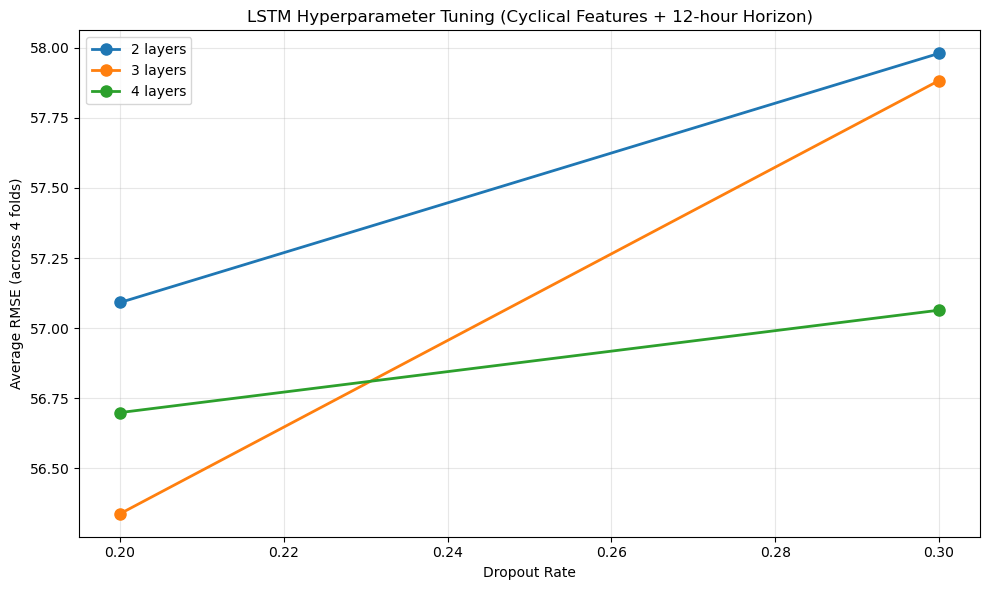

In [17]:
#Hyperparameter Tuning - Cyclical Features (12-hour horizon, all 4 CV folds)
layer_options_cyclic = [2, 3, 4]
dropout_options_cyclic = [0.2, 0.3]
n_features = scaled_combined.shape[1]  # 7 features: load + 6 cyclical
horizon = 12

tuning_results_cyclic = []

for n_layers in layer_options_cyclic:
    for dropout_rate in dropout_options_cyclic:
        print(f"\nTesting {n_layers} layers, dropout rate {dropout_rate} (cyclical + 12-hour horizon)")
        rmse_cv_scores = []
        mape_cv_scores = []
        
        # Test across all 4 CV folds
        for cv_idx, cv in enumerate(cv_splits, 1):
            print(f"  CV{cv_idx}...", end=' ', flush=True)
            metrics, _ = train_evaluate_lstm_cyclic_horizon(cv, data_by_year_cyclic, horizon=horizon,
                                                           n_features=n_features, n_layers=n_layers, 
                                                           dropout_rate=dropout_rate, epochs=50)
            rmse_cv_scores.append(metrics['RMSE'])
            mape_cv_scores.append(metrics['MAPE'])
            print(f"RMSE={metrics['RMSE']:.2f}, MAPE={metrics['MAPE']:.2f}%")
        
        # Average across folds
        avg_rmse = np.mean(rmse_cv_scores)
        avg_mape = np.mean(mape_cv_scores)
        
        tuning_results_cyclic.append({
            'layers': n_layers,
            'dropout': dropout_rate,
            'RMSE': avg_rmse,
            'MAPE': avg_mape,
            'rmse_scores': rmse_cv_scores,
            'mape_scores': mape_cv_scores
        })
        print(f"  Average RMSE={avg_rmse:.2f}, MAPE={avg_mape:.2f}%")

#Find best configuration
best_config_cyclic = min(tuning_results_cyclic, key=lambda x: x['RMSE'])
print(f"\n=== Best configuration (cyclical + 12-hour): {best_config_cyclic['layers']} layers, {best_config_cyclic['dropout']} dropout rate ===")
print(f"Best Avg RMSE: {best_config_cyclic['RMSE']:.2f}, Avg MAPE: {best_config_cyclic['MAPE']:.2f}%")
print(f"RMSE across folds: {[f'{x:.2f}' for x in best_config_cyclic['rmse_scores']]}")

#Plot tuning results
plt.figure(figsize=(10, 6))
for l in layer_options_cyclic:
    layer_data = [r for r in tuning_results_cyclic if r['layers'] == l]
    plt.plot([r['dropout'] for r in layer_data], [r['RMSE'] for r in layer_data], 
             marker='o', linewidth=2, markersize=8, label=f'{l} layers')
plt.xlabel('Dropout Rate')
plt.ylabel('Average RMSE (across 4 folds)')
plt.title('LSTM Hyperparameter Tuning (Cyclical Features + 12-hour Horizon)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
#Cyclical Fatures Evaluations - Default, Tuned (6,12,24-hr horizon)
n_features = scaled_combined.shape[1]

default_layers   = 3
default_dropout  = 0.2
tuned_layers     = best_config_cyclic['layers']
tuned_dropout    = best_config_cyclic['dropout']

horizon_results = []

for h in [6,12,24]:
    print(f"\n{'='*55}")
    print(f"Horizon: {h} hours")
    print(f"{'='*55}")

    #Default parameters
    print(f"\nDefault (layers={default_layers}, dropout={default_dropout})")
    rmse_def, mape_def = [], []
    for cv_idx, cv in enumerate(cv_splits, 1):
        print(f"  CV{cv_idx}...", end=' ', flush=True)
        metrics, _ = train_evaluate_lstm_cyclic_horizon(
            cv, data_by_year_cyclic,
            seq_length=24, horizon=h,
            n_features=n_features,
            n_layers=default_layers,
            dropout_rate=default_dropout,
            epochs=50
        )
        rmse_def.append(metrics['RMSE'])
        mape_def.append(metrics['MAPE'])
        print(f"RMSE={metrics['RMSE']:.2f}, MAPE={metrics['MAPE']:.2f}%")
    print(f"  Avg RMSE={np.mean(rmse_def):.2f}, Avg MAPE={np.mean(mape_def):.2f}%")

    #Tuned parameters
    print(f"\nTuned  (layers={tuned_layers}, dropout={tuned_dropout})")
    rmse_tun, mape_tun = [], []
    for cv_idx, cv in enumerate(cv_splits, 1):
        print(f"  CV{cv_idx}...", end=' ', flush=True)
        metrics, _ = train_evaluate_lstm_cyclic_horizon(
            cv, data_by_year_cyclic,
            seq_length=24, horizon=h,
            n_features=n_features,
            n_layers=tuned_layers,
            dropout_rate=tuned_dropout,
            epochs=50
        )
        rmse_tun.append(metrics['RMSE'])
        mape_tun.append(metrics['MAPE'])
        print(f"RMSE={metrics['RMSE']:.2f}, MAPE={metrics['MAPE']:.2f}%")
    print(f"  Avg RMSE={np.mean(rmse_tun):.2f}, Avg MAPE={np.mean(mape_tun):.2f}%")

    horizon_results.append({
        'horizon': h,
        'default_rmse': np.mean(rmse_def), 'default_mape': np.mean(mape_def),
        'default_rmse_folds': rmse_def,    'default_mape_folds': mape_def,
        'tuned_rmse': np.mean(rmse_tun),   'tuned_mape': np.mean(mape_tun),
        'tuned_rmse_folds': rmse_tun,      'tuned_mape_folds': mape_tun,
    })

print(f"\n{'Horizon':<10} {'Default RMSE':<16} {'Tuned RMSE':<16} {'Default MAPE':<16} {'Tuned MAPE'}")
for r in horizon_results:
    print(f"{r['horizon']:<10} {r['default_rmse']:<16.2f} {r['tuned_rmse']:<16.2f} {r['default_mape']:<16.2f} {r['tuned_mape']:.2f}%")

#Best horizon for default and tuned - lowest RMSE average across folds
best_horizon_default = min(horizon_results, key=lambda r: r['default_rmse'])['horizon']
best_horizon_tuned   = min(horizon_results, key=lambda r: r['tuned_rmse'])['horizon']

print(f"Best horizon for Default params: {best_horizon_default}h  (Avg RMSE={min(r['default_rmse'] for r in horizon_results):.2f})")
print(f"Best horizon for Tuned params:   {best_horizon_tuned}h  (Avg RMSE={min(r['tuned_rmse']   for r in horizon_results):.2f})")




Horizon: 6 hours

Default (layers=3, dropout=0.2)
275/275 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
RMSE=47.99, MAPE=2.91%
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
RMSE=48.81, MAPE=2.72%
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
RMSE=41.14, MAPE=2.31%
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
RMSE=55.33, MAPE=3.07%
  Avg RMSE=48.32, Avg MAPE=2.76%

Tuned  (layers=3, dropout=0.2)
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
RMSE=47.35, MAPE=2.91%
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
RMSE=47.96, MAPE=2.61%
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
RMSE=42.24, MAPE=2.52%
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
RMSE=49.74, MAPE=2.82%
  Avg RMSE=46.82, Avg MAPE=2.72%

Horizon: 12 hours

Default (layers=3, dropout=0.2)
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
RMSE=54.30, MAPE=3.43%
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
RMSE=60.13, MAPE=3.50%
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
RMSE=51.86, MAPE=2.99%
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
RMSE=64.11, MAPE=3.60%
  Avg RMSE=57.60, Avg MAPE

## 5. Model Evaluation


Model for 6-hour horizon...
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step
Results (6h): RMSE=50.02, MAPE=2.65%


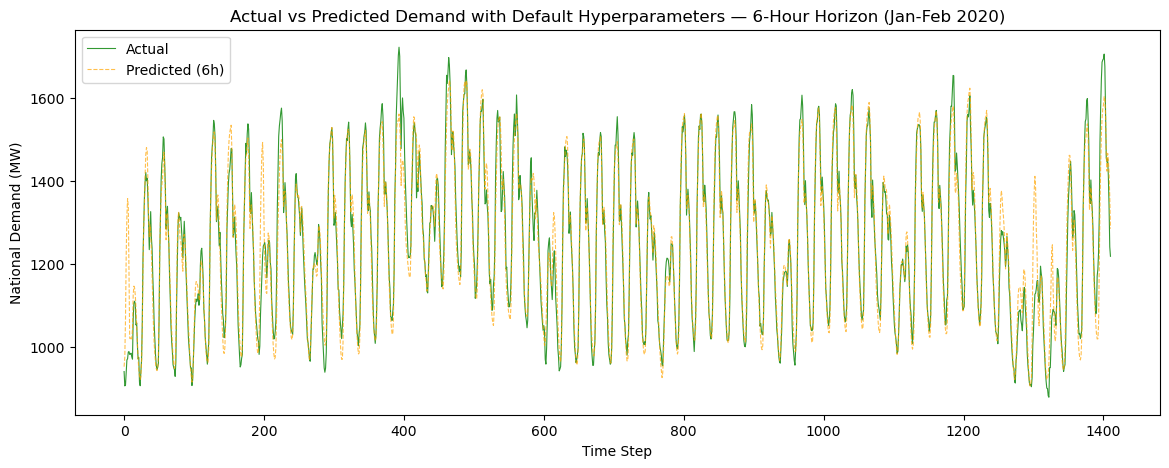


Model for 12-hour horizon...
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step
Results (12h): RMSE=67.64, MAPE=3.51%


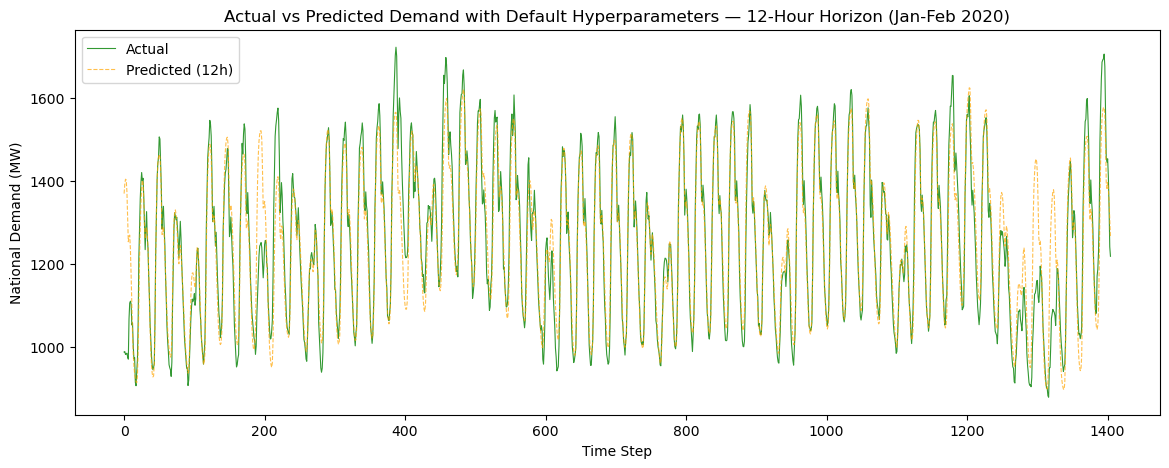


Model for 24-hour horizon...
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step
Results (24h): RMSE=68.70, MAPE=3.73%


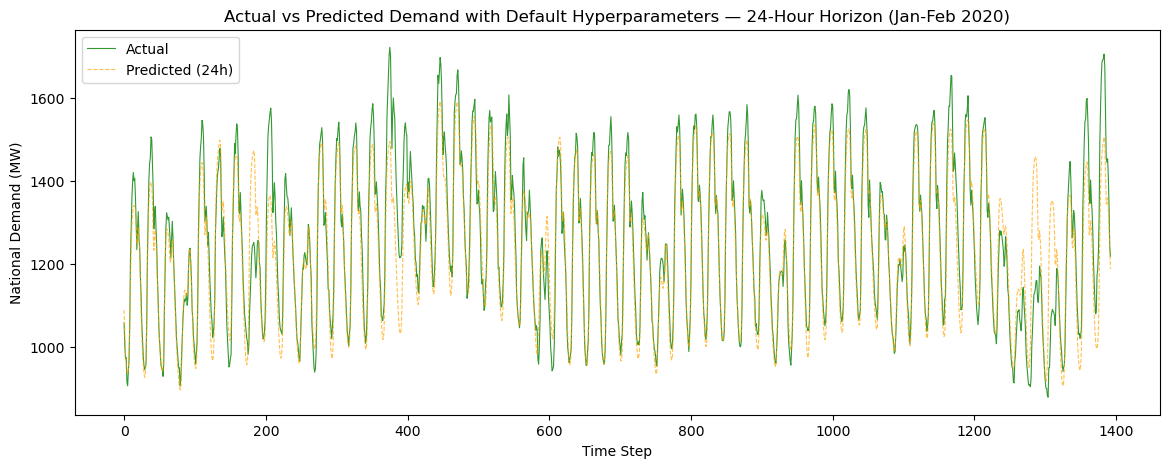

In [19]:
#Test Jan-Feb 2020 (Cyclical Features - Default, 6,12,24-hr horizons)
train_years = [2015, 2016, 2017, 2018, 2019]
train_data_cyclic_default = np.concatenate([data_by_year_cyclic[year] for year in train_years])

mask_test = (LSTM_data.index.year == 2020) & (LSTM_data.index.month <= 2)
test_data_cyclic_default = scaled_combined[mask_test]
last_24_train_cyclic_default = train_data_cyclic_default[-seq_length:]
test_data_full_cyclic_default = np.concatenate([last_24_train_cyclic_default, test_data_cyclic_default])

n_layers_default = 3
dropout_rate_default = 0.2
test_metrics_default_all = {}

for h in [6, 12, 24]:
    X_train_list, y_train_list = [], []
    for i in range(len(train_data_cyclic_default) - seq_length - h + 1):
        X_train_list.append(train_data_cyclic_default[i:i+seq_length])
        y_train_list.append(train_data_cyclic_default[i+seq_length+h-1, 0])
    X_train_cyclic_default = np.array(X_train_list)
    y_train_cyclic_default = np.array(y_train_list)

    X_test_list, y_test_list = [], []
    for i in range(len(test_data_full_cyclic_default) - seq_length - h + 1):
        X_test_list.append(test_data_full_cyclic_default[i:i+seq_length])
        y_test_list.append(test_data_full_cyclic_default[i+seq_length+h-1, 0])
    X_test_cyclic_default = np.array(X_test_list)
    y_test_cyclic_default = np.array(y_test_list)

    print(f"\nModel for {h}-hour horizon...")
    model_cyclic_default = create_lstm_model_cyclic(seq_length, n_features, n_layers_default, dropout_rate_default)
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    val_split = 0.1
    val_steps = int(len(X_train_cyclic_default) * val_split)
    model_cyclic_default.fit(
        X_train_cyclic_default[:-val_steps], y_train_cyclic_default[:-val_steps],
        epochs=50, batch_size=32,
        validation_data=(X_train_cyclic_default[-val_steps:], y_train_cyclic_default[-val_steps:]),
        callbacks=[early_stop], verbose=0
    )

    y_pred = model_cyclic_default.predict(X_test_cyclic_default)
    y_test_inv = scaler_load.inverse_transform(y_test_cyclic_default.reshape(-1, 1)).flatten()
    y_pred_inv = scaler_load.inverse_transform(y_pred).flatten()

    metrics = evaluate_model(y_test_inv, y_pred_inv)
    test_metrics_default_all[h] = metrics
    print(f"Results ({h}h): RMSE={metrics['RMSE']:.2f}, MAPE={metrics['MAPE']:.2f}%")

    plt.figure(figsize=(14, 5))
    plt.plot(y_test_inv, color='green', linewidth=0.8, label='Actual', alpha=0.8)
    plt.plot(y_pred_inv, color='orange', linewidth=0.8, linestyle='--', label=f'Predicted ({h}h)', alpha=0.7)
    plt.title(f'Actual vs Predicted Demand with Default Hyperparameters — {h}-Hour Horizon (Jan-Feb 2020)')
    plt.xlabel('Time Step')
    plt.ylabel('National Demand (MW)')
    plt.legend()
    plt.show()


Tuned configuration: 3 layers, dropout=0.2

Model for 6-hour horizon...
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step
Results (6h): RMSE=57.84, MAPE=3.16%


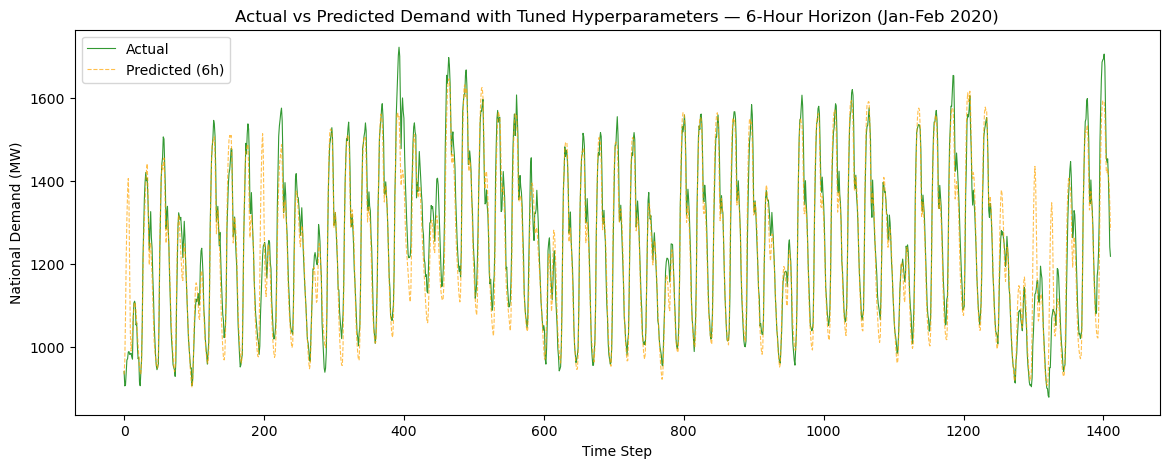


Model for 12-hour horizon...
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step
Results (12h): RMSE=64.08, MAPE=3.37%


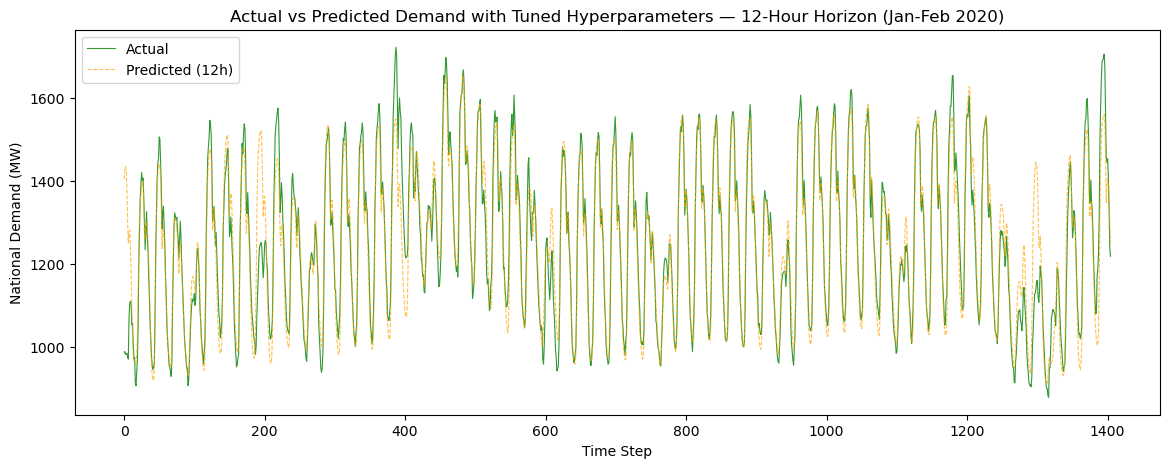


Model for 24-hour horizon...
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Results (24h): RMSE=67.18, MAPE=3.54%


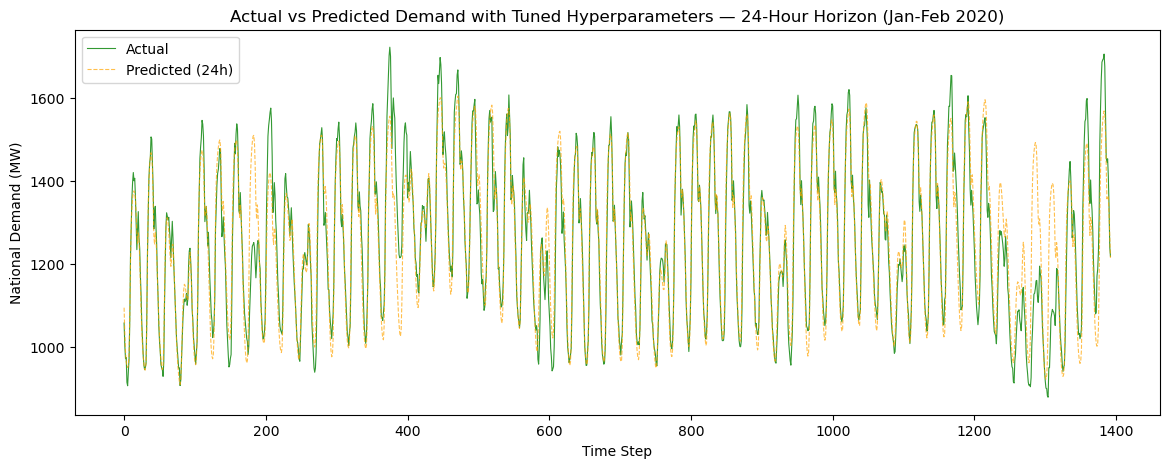


Horizon    Default RMSE     Tuned RMSE       Default MAPE     Tuned MAPE
6h         50.02            57.84            2.65             3.16%
12h         67.64            64.08            3.51             3.37%
24h         68.70            67.18            3.73             3.54%


In [20]:
#Test Jan-Feb 2020 (Cyclical Features - Tuned, 6,12,24-hr horizons)
train_years = [2015, 2016, 2017, 2018, 2019]
train_data_cyclic_tuned = np.concatenate([data_by_year_cyclic[year] for year in train_years])

mask_test = (LSTM_data.index.year == 2020) & (LSTM_data.index.month <= 2)
test_data_cyclic_tuned = scaled_combined[mask_test]
last_seq_train_cyclic_tuned = train_data_cyclic_tuned[-seq_length:]
test_data_full_cyclic_tuned = np.concatenate([last_seq_train_cyclic_tuned, test_data_cyclic_tuned])

n_layers_tuned = best_config_cyclic['layers']
dropout_rate_tuned = best_config_cyclic['dropout']
test_metrics_tuned_all = {}

print(f"Tuned configuration: {n_layers_tuned} layers, dropout={dropout_rate_tuned}")

for h in [6, 12, 24]:
    X_train_list, y_train_list = [], []
    for i in range(len(train_data_cyclic_tuned) - seq_length - h + 1):
        X_train_list.append(train_data_cyclic_tuned[i:i+seq_length])
        y_train_list.append(train_data_cyclic_tuned[i+seq_length+h-1, 0])
    X_train_cyclic_tuned = np.array(X_train_list)
    y_train_cyclic_tuned = np.array(y_train_list)

    X_test_list, y_test_list = [], []
    for i in range(len(test_data_full_cyclic_tuned) - seq_length - h + 1):
        X_test_list.append(test_data_full_cyclic_tuned[i:i+seq_length])
        y_test_list.append(test_data_full_cyclic_tuned[i+seq_length+h-1, 0])
    X_test_cyclic_tuned = np.array(X_test_list)
    y_test_cyclic_tuned = np.array(y_test_list)

    print(f"\nModel for {h}-hour horizon...")
    model_cyclic_tuned = create_lstm_model_cyclic(seq_length, n_features, n_layers_tuned, dropout_rate_tuned)
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    val_split = 0.1
    val_steps = int(len(X_train_cyclic_tuned) * val_split)
    model_cyclic_tuned.fit(
        X_train_cyclic_tuned[:-val_steps], y_train_cyclic_tuned[:-val_steps],
        epochs=50, batch_size=32,
        validation_data=(X_train_cyclic_tuned[-val_steps:], y_train_cyclic_tuned[-val_steps:]),
        callbacks=[early_stop], verbose=0
    )

    y_pred = model_cyclic_tuned.predict(X_test_cyclic_tuned)
    y_test_inv = scaler_load.inverse_transform(y_test_cyclic_tuned.reshape(-1, 1)).flatten()
    y_pred_inv = scaler_load.inverse_transform(y_pred).flatten()

    metrics = evaluate_model(y_test_inv, y_pred_inv)
    test_metrics_tuned_all[h] = metrics
    print(f"Results ({h}h): RMSE={metrics['RMSE']:.2f}, MAPE={metrics['MAPE']:.2f}%")

    plt.figure(figsize=(14, 5))
    plt.plot(y_test_inv, color='green', linewidth=0.8, label='Actual', alpha=0.8)
    plt.plot(y_pred_inv, color='orange', linewidth=0.8, linestyle='--', label=f'Predicted ({h}h)', alpha=0.7)
    plt.title(f'Actual vs Predicted Demand with Tuned Hyperparameters — {h}-Hour Horizon (Jan-Feb 2020)')
    plt.xlabel('Time Step')
    plt.ylabel('National Demand (MW)')
    plt.legend()
    plt.show()

# Summary comparison
print(f"\n{'Horizon':<10} {'Default RMSE':<16} {'Tuned RMSE':<16} {'Default MAPE':<16} {'Tuned MAPE'}")
for h in [6, 12, 24]:
    print(f"{h}h{'':<8} {test_metrics_default_all[h]['RMSE']:<16.2f} {test_metrics_tuned_all[h]['RMSE']:<16.2f} {test_metrics_default_all[h]['MAPE']:<16.2f} {test_metrics_tuned_all[h]['MAPE']:.2f}%")


In [34]:
#SHAP Feature Importance - 6, 12, 24-hr horizons
import shap

feature_name = ['load', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
n_features = scaled_combined.shape[1]

shap_results = {}

train_years_shap = [2015, 2016, 2017, 2018, 2019]
train_data_shap = np.concatenate([data_by_year_cyclic[year] for year in train_years_shap])

mask_test_shap = (LSTM_data.index.year == 2020) & (LSTM_data.index.month <= 2)
test_data_shap = scaled_combined[mask_test_shap]
test_data_full_shap = np.concatenate([train_data_shap[-seq_length:], test_data_shap])

n_layers_shap  = best_config_cyclic['layers']
dropout_shap   = best_config_cyclic['dropout']

for h in [6, 12, 24]:
    print(f"\nTraining SHAP — {h}-hour horizon...")

    X_tr, y_tr = [], []
    for i in range(len(train_data_shap) - seq_length - h + 1):
        X_tr.append(train_data_shap[i:i+seq_length])
        y_tr.append(train_data_shap[i+seq_length+h-1, 0])
    X_tr = np.array(X_tr)
    y_tr = np.array(y_tr)

    X_te, y_te = [], []
    for i in range(len(test_data_full_shap) - seq_length - h + 1):
        X_te.append(test_data_full_shap[i:i+seq_length])
        y_te.append(test_data_full_shap[i+seq_length+h-1, 0])
    X_te = np.array(X_te)
    y_te = np.array(y_te)

    model_shap = create_lstm_model_cyclic(seq_length, n_features, n_layers_shap, dropout_shap)
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    val_steps  = int(len(X_tr) * 0.1)
    model_shap.fit(
        X_tr[:-val_steps], y_tr[:-val_steps],
        epochs=50, batch_size=32,
        validation_data=(X_tr[-val_steps:], y_tr[-val_steps:]),
        callbacks=[early_stop], verbose=0
    )

    # SHAP background: 100 random training samples
    background = X_tr[np.random.choice(len(X_tr), 100, replace=False)]
    X_explain  = X_te[:200]

    explainer   = shap.GradientExplainer(model_shap, background)
    shap_values = explainer.shap_values(X_explain)

    shap_arr = shap_values[0] if isinstance(shap_values, list) else shap_values
    
    mean_abs_shap    = np.mean(np.abs(shap_arr), axis=1)   
    feature_importance = np.mean(mean_abs_shap, axis=0)    

    shap_results[h] = {
        'shap_values': shap_arr,
        'feature_importance': feature_importance
    }
    print(f"Done. feature_importance shape: {feature_importance.shape}")



Training SHAP — 6-hour horizon...


c:\Users\emran\anaconda3\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_544
Received: inputs=['Tensor(shape=(200, 24, 7))']
  warnings.warn(msg)
c:\Users\emran\anaconda3\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_544
Received: inputs=['Tensor(shape=(50, 24, 7))']
  warnings.warn(msg)


Done. feature_importance shape: (7, 1)

Training SHAP — 12-hour horizon...


c:\Users\emran\anaconda3\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_552
Received: inputs=['Tensor(shape=(200, 24, 7))']
  warnings.warn(msg)
c:\Users\emran\anaconda3\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_552
Received: inputs=['Tensor(shape=(50, 24, 7))']
  warnings.warn(msg)


Done. feature_importance shape: (7, 1)

Training SHAP — 24-hour horizon...


c:\Users\emran\anaconda3\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_560
Received: inputs=['Tensor(shape=(200, 24, 7))']
  warnings.warn(msg)
c:\Users\emran\anaconda3\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_560
Received: inputs=['Tensor(shape=(50, 24, 7))']
  warnings.warn(msg)


Done. feature_importance shape: (7, 1)


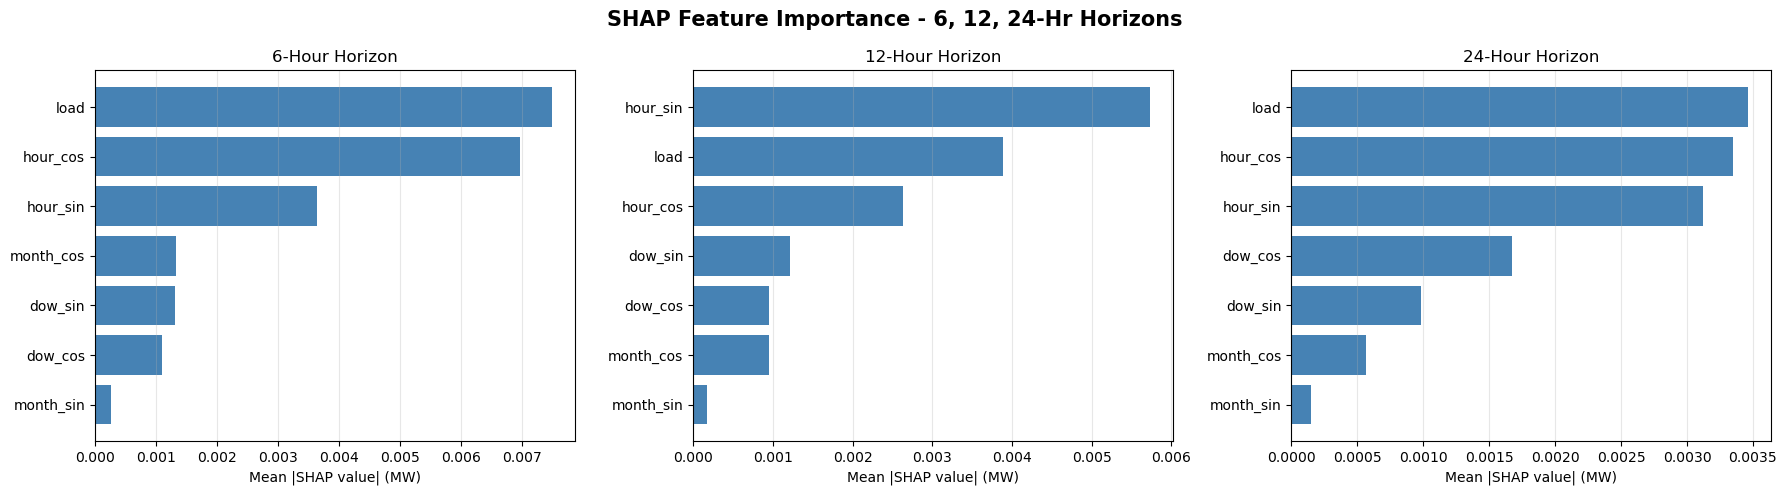

In [35]:
#SHAP Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, h in zip(axes, [6, 12, 24]):
    fi = shap_results[h]['feature_importance'].flatten()  
    sorted_idx = np.argsort(fi)
    ax.barh([feature_name[int(i)] for i in sorted_idx], fi[sorted_idx], color='steelblue')
    ax.set_xlabel('Mean |SHAP value| (MW)')
    ax.set_title(f'{h}-Hour Horizon')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('SHAP Feature Importance - 6, 12, 24-Hr Horizons', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()